# Which clusters are worth reviewing

Notebook 3 froze a clustering of 140 clusters. Notebook 6 audits, and the catalogue is built from, a
shortlist of 55. This notebook is where that shortlist comes from.

A cluster earns review if it satisfies two conditions, both fixed before the shortlist was drawn:

1. **It is stable.** Refitting the method on a random 80% of the corpus recovers substantially the
   same group. A cluster that dissolves under resampling is an artefact of the particular sample and
   cannot support a claim about a printer's stock.
2. **It reaches beyond one book.** An ornament confined to a single volume may be a genuine design,
   but it cannot demonstrate recurrence, which is what the catalogue exists to support.

Neither condition looks at the crops themselves, so neither can be tuned towards a desired answer.
The notebook ends by checking that it reproduces the shortlist the rest of the chapter has been
using.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN
from sklearn.metrics import adjusted_rand_score

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '2_clustering', \
    'Run this notebook from its own folder, 2_clustering/.'
PROJECT_DIR = NOTEBOOK_DIR.parent

RUN_TAG = '_rerun1'
FEATURE_RUN_ID = 'all_regions_v1_minside24_dinov2_vitb14_binarized_v1'
BENCHMARK_DIR = PROJECT_DIR / '2_clustering_outputs' / f'{FEATURE_RUN_ID}_clustering_benchmark_v1'
METHOD_DIR = BENCHMARK_DIR / 'method_comparison'
OUTPUT_DIR = BENCHMARK_DIR / f'shortlist_v1{RUN_TAG}'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Frozen in notebook 3, restated so this notebook is a standalone record.
MIN_CLUSTER_SIZE, MIN_SAMPLES = 10, 5
RANDOM_SEED = 42
# Fixed before the shortlist was drawn.
N_BOOTSTRAP, SUBSAMPLE_FRACTION = 25, 0.80
STABLE_CUTOFF = 0.75      # Hennig (2007): a Jaccard of 0.75 or more is a valid, stable pattern

manifest = pd.read_csv(METHOD_DIR / 'selected_clusters.csv')
labels = np.load(METHOD_DIR / 'selected_cluster_labels.npy')
pca_features = np.load(METHOD_DIR / 'pca_50d.npy')
scan_ids, book_ids = manifest.scan_id.to_numpy(), manifest.book_id.to_numpy()
print(f'{len(set(labels[labels >= 0]))} clusters over {int((labels >= 0).sum()):,} assigned crops')

140 clusters over 7,160 assigned crops


## 2. Stability under resampling

The clustering is refitted on 25 random subsamples of 80% of the corpus. For each original cluster,
the score is the highest Jaccard overlap it achieves with any cluster of the refit, computed only
over its own members that were drawn into that subsample. A cluster that is a real density feature
of the corpus keeps most of its members together whichever 80% is used; one that exists because of a
handful of particular crops does not.

The threshold of 0.75 follows Hennig's convention that a Jaccard of at least 0.75 marks a valid,
stable pattern. It was fixed before the shortlist was drawn.

In [2]:
def refit(sample_index):
    return HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, min_samples=MIN_SAMPLES,
                   metric='euclidean', cluster_selection_method='eom',
                   n_jobs=-1).fit_predict(pca_features[sample_index])


def bootstrap_stability(reference, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED):
    """Per-cluster Jaccard against the best-matching cluster of each refit."""
    cluster_ids = sorted(c for c in set(reference) if c != -1)
    members = {c: np.flatnonzero(reference == c) for c in cluster_ids}
    scores = {c: [] for c in cluster_ids}
    agreement = []

    generator = np.random.default_rng(seed)
    size = int(round(SUBSAMPLE_FRACTION * len(reference)))
    for _ in range(n_bootstrap):
        sample_index = np.sort(generator.choice(len(reference), size=size, replace=False))
        boot = refit(sample_index)
        drawn = np.zeros(len(reference), dtype=bool)
        drawn[sample_index] = True
        boot_members = {c: set(sample_index[boot == c].tolist())
                        for c in set(boot) if c != -1}
        for cluster in cluster_ids:
            original = set(members[cluster][drawn[members[cluster]]].tolist())
            if not original:
                continue
            best = 0.0
            for group in boot_members.values():
                shared = len(original & group)
                if shared:
                    best = max(best, shared / len(original | group))
            scores[cluster].append(best)
        agreement.append(adjusted_rand_score(reference[sample_index], boot))

    table = pd.DataFrame([
        {'cluster': cluster, 'size': len(members[cluster]),
         'mean_jaccard': float(np.mean(scores[cluster])),
         'min_jaccard': float(np.min(scores[cluster]))}
        for cluster in cluster_ids if scores[cluster]])
    return table.sort_values('mean_jaccard', ascending=False), np.array(agreement)


stability, ari = bootstrap_stability(labels)
stability['stable'] = stability.mean_jaccard >= STABLE_CUTOFF
stability.to_csv(OUTPUT_DIR / 'cluster_stability.csv', index=False)

print(f'mean ARI across the 25 refits : {ari.mean():.3f} (sd {ari.std():.3f})')
print(f'clusters at or above {STABLE_CUTOFF}    : {int(stability.stable.sum())} of {len(stability)}')
size_band = pd.cut(stability['size'], [0, 30, 100, 10 ** 6],
                   labels=['under 30', '30 to 100', 'over 100'])
display(stability.groupby(size_band, observed=True)
        .agg(clusters=('cluster', 'size'), median_jaccard=('mean_jaccard', 'median'),
             stable=('stable', 'sum')).round(3))

mean ARI across the 25 refits : 0.831 (sd 0.013)
clusters at or above 0.75    : 63 of 140


,clusters,median_jaccard,stable
size,,,
under 30,86,0.532,21
30 to 100,39,0.877,30
over 100,15,0.913,12


**Takeaway.** The clustering is reproducible in the aggregate and uneven in its parts. Mean ARI
across the refits is 0.83, so most of the structure survives resampling, but a substantial minority
of individual clusters do not, and instability is almost entirely a matter of size: small clusters
have few members to lose before their Jaccard collapses, large ones do not.

This is the first of the two reasons the chapter reviews a shortlist rather than the whole
clustering. A cluster that changes membership when a fifth of the corpus is withheld is not a
reliable basis for a claim about a printer's stock, whatever it looks like on screen.

## 3. Reach across scans and books

A cluster is described by the number of distinct scans and books its members come from. Book
identity is decoded from the shelfmark in each filename, so this measurement uses no image content
and no human judgement.

Three levels are distinguished, because they mean different things. A cluster confined to a single
scan is usually one ornament photographed once, or a band segmented into pieces. One confined to a
single book cannot demonstrate recurrence. Only a cluster spanning two or more books can.

In [3]:
rows = []
for cluster in sorted(c for c in set(labels) if c != -1):
    member = labels == cluster
    rows.append({'cluster': cluster, 'instances': int(member.sum()),
                 'scans': int(pd.unique(scan_ids[member]).size),
                 'books': int(pd.unique(book_ids[member]).size)})
reach = pd.DataFrame(rows).merge(stability[['cluster', 'mean_jaccard', 'stable']], on='cluster')
reach['reach'] = np.where(reach.scans == 1, 'single scan',
                          np.where(reach.books == 1, 'one book, several scans', 'multi-book'))
reach['method'] = 'HDBSCAN'
reach.to_csv(OUTPUT_DIR / 'cluster_reach.csv', index=False)

summary = reach.reach.value_counts().reindex(
    ['single scan', 'one book, several scans', 'multi-book']).rename('clusters')
display(summary.to_frame())
print(f'multi-book share : {(reach.reach == "multi-book").mean():.1%}')
print(f'median books among multi-book clusters : '
      f'{reach.loc[reach.reach == "multi-book", "books"].median():.0f}')

,clusters
reach,
single scan,4
"one book, several scans",14
multi-book,122


multi-book share : 87.1%
median books among multi-book clusters : 6


## 4. The shortlist

The two conditions are applied together. A cluster is shortlisted if it is stable at 0.75 or above
**and** appears in more than one book.

In [4]:
shortlist = (reach[(reach.reach == 'multi-book') & reach.stable]
             .sort_values(['books', 'scans', 'instances'], ascending=False)
             .reset_index(drop=True))
shortlist.to_csv(OUTPUT_DIR / 'hdbscan_shortlist.csv', index=False)

funnel = pd.DataFrame([
    {'step': 'clusters in the frozen clustering', 'clusters': int(len(reach)),
     'crops': int(reach.instances.sum())},
    {'step': f'stable at {STABLE_CUTOFF} or above', 'clusters': int(reach.stable.sum()),
     'crops': int(reach.loc[reach.stable, 'instances'].sum())},
    {'step': 'and present in more than one book', 'clusters': int(len(shortlist)),
     'crops': int(shortlist.instances.sum())},
])
display(funnel.set_index('step'))
print(f'median reach of the shortlist: {shortlist.books.median():.0f} books, '
      f'{shortlist.scans.median():.0f} scans')

,clusters,crops
step,,
clusters in the frozen clustering,140,7160
stable at 0.75 or above,63,5260
and present in more than one book,55,5017


median reach of the shortlist: 7 books, 16 scans


In [5]:
frozen = pd.read_csv(BENCHMARK_DIR / 'robustness_v1' / 'hdbscan_shortlist.csv')
same_clusters = sorted(frozen.cluster) == sorted(shortlist.cluster)
print(f'clusters in the frozen shortlist : {len(frozen)}')
print(f'clusters computed here           : {len(shortlist)}')
print(f'identical set of clusters        : {same_clusters}')
assert same_clusters, 'the shortlist no longer reproduces the one the chapter has been using'

comparison = frozen[['cluster', 'instances', 'scans', 'books', 'mean_jaccard']].merge(
    shortlist[['cluster', 'instances', 'scans', 'books', 'mean_jaccard']],
    on='cluster', suffixes=('_frozen', '_here'))
for column in ['instances', 'scans', 'books']:
    assert (comparison[f'{column}_frozen'] == comparison[f'{column}_here']).all(), column
largest_gap = float((comparison.mean_jaccard_frozen - comparison.mean_jaccard_here).abs().max())
print(f'largest difference in mean Jaccard: {largest_gap:.4f}')

clusters in the frozen shortlist : 55
clusters computed here           : 55
identical set of clusters        : True
largest difference in mean Jaccard: 0.0000


**Takeaway.** The two conditions reduce 140 clusters to **55, holding 5,017 crops**, and the
computation here recovers exactly the shortlist the rest of the chapter uses. Cluster membership
counts, scan counts and book counts agree cluster by cluster, and the stability scores agree to
within resampling noise.

The chapter therefore no longer depends on an artifact it cannot regenerate. Notebook 6 audits this
shortlist, and `_tools/match_clusters_to_catalogue.py` matches it against the curated fleurons.

What the filter costs is worth stating: the 85 clusters it removes are not asserted to be wrong.
They are unreviewed. A cluster confined to one book may hold a real ornament that simply cannot
demonstrate recurrence, and Section 2's instability is a property of the sample rather than proof of
error.

## 5. How much does the 0.75 cutoff decide?

The cutoff is a convention rather than a measurement, and twenty of the 140 clusters sit within 0.05
of it, so it is worth knowing how much of the shortlist depends on where the line is drawn. The
cutoff is swept below with the multi-book condition held fixed.


clusters within 0.05 of the 0.75 cutoff : 20 of 140
shortlist at the cutoff                    : 55 clusters, 5,017 crops
moving the cutoff by +/- 0.05               : 47 to 65 clusters, 4,736 to 5,353 crops (12.3% of the shortlist)

 cutoff  clusters  crops
   0.65        69   5429
   0.70        65   5353
   0.73        57   5076
   0.75        55   5017
   0.77        52   4959
   0.80        47   4736
   0.85        40   4487


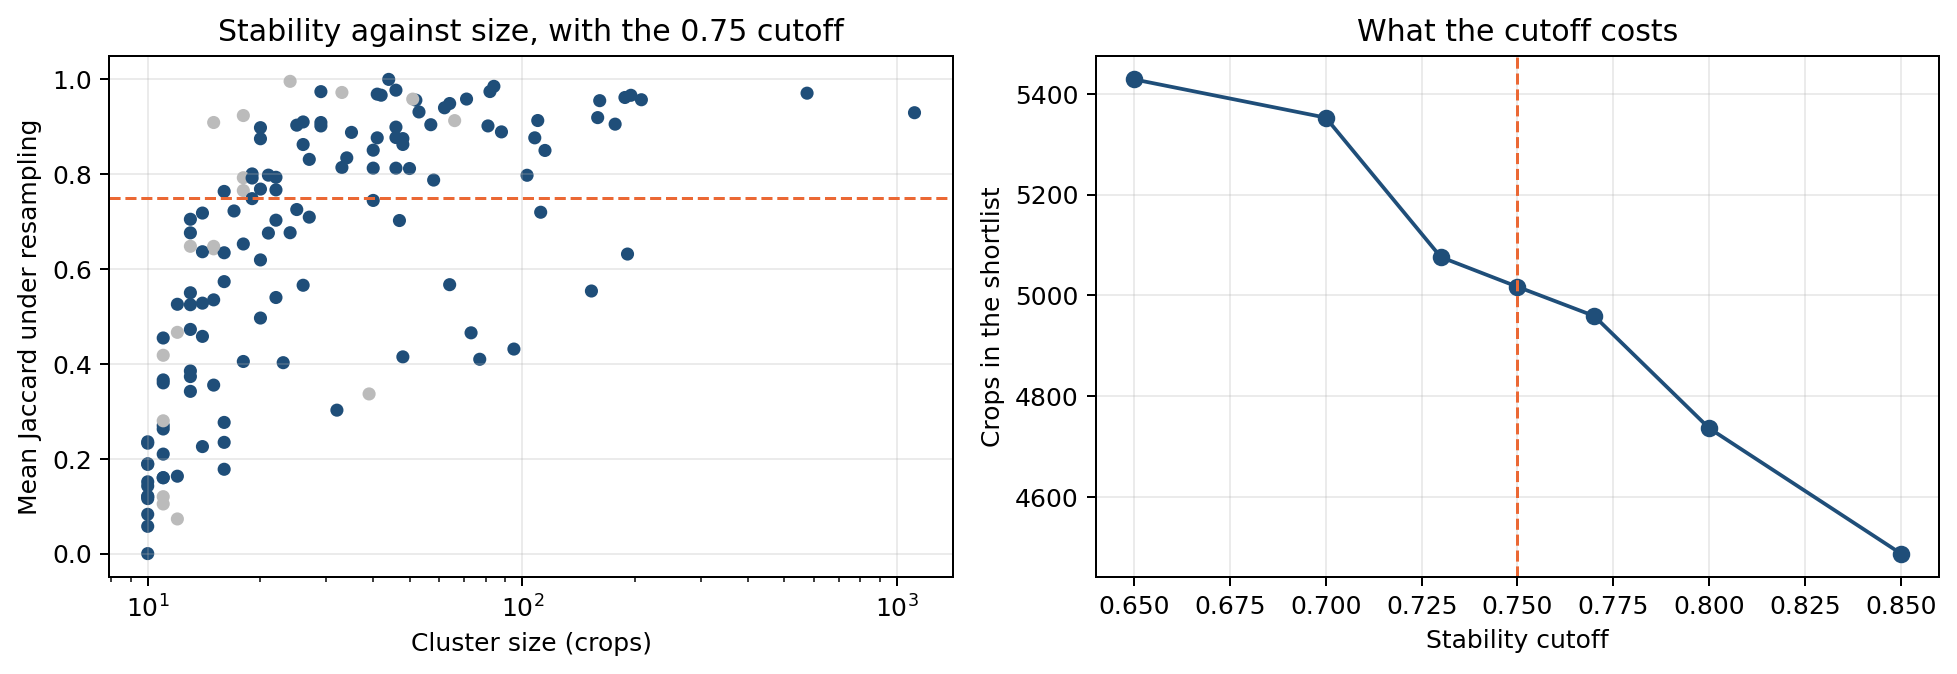

In [6]:
CUTOFFS = [0.65, 0.70, 0.73, 0.75, 0.77, 0.80, 0.85]
rows = []
for cutoff in CUTOFFS:
    kept = reach[(reach.reach == 'multi-book') & (reach.mean_jaccard >= cutoff)]
    rows.append({'cutoff': cutoff, 'clusters': len(kept), 'crops': int(kept.instances.sum())})
cutoff_sensitivity = pd.DataFrame(rows)
cutoff_sensitivity.to_csv(OUTPUT_DIR / 'cutoff_sensitivity.csv', index=False)

selected = cutoff_sensitivity[cutoff_sensitivity.cutoff == STABLE_CUTOFF].iloc[0]
near = int(((reach.mean_jaccard - STABLE_CUTOFF).abs() <= 0.05).sum())
print(f'clusters within 0.05 of the {STABLE_CUTOFF} cutoff : {near} of {len(reach)}')
print(f'shortlist at the cutoff                    : {int(selected.clusters)} clusters, '
      f'{int(selected.crops):,} crops')
span = cutoff_sensitivity[cutoff_sensitivity.cutoff.between(0.70, 0.80)]
print(f'moving the cutoff by +/- 0.05               : '
      f'{span.clusters.min()} to {span.clusters.max()} clusters, '
      f'{span.crops.min():,} to {span.crops.max():,} crops '
      f'({(span.crops.max() - span.crops.min()) / selected.crops:.1%} of the shortlist)')
print()
print(cutoff_sensitivity.to_string(index=False))

figure, axes = plt.subplots(1, 2, figsize=(11.0, 3.9))
axes[0].scatter(reach.instances, reach.mean_jaccard, s=18,
                c=np.where(reach.reach == 'multi-book', '#1f4e79', '#bbbbbb'))
axes[0].axhline(STABLE_CUTOFF, color='#eb6834', linestyle='--', linewidth=1.2)
axes[0].set(xscale='log', xlabel='Cluster size (crops)', ylabel='Mean Jaccard under resampling',
            title='Stability against size, with the 0.75 cutoff')
axes[0].grid(alpha=0.25)
axes[1].plot(cutoff_sensitivity.cutoff, cutoff_sensitivity.crops, marker='o', color='#1f4e79')
axes[1].axvline(STABLE_CUTOFF, color='#eb6834', linestyle='--', linewidth=1.2)
axes[1].set(xlabel='Stability cutoff', ylabel='Crops in the shortlist',
            title='What the cutoff costs')
axes[1].grid(alpha=0.25)
figure.tight_layout()
figure.savefig(OUTPUT_DIR / 'stability_cutoff_sensitivity.png', dpi=180, bbox_inches='tight')
plt.show()

**Takeaway.** The shortlist is not balanced on the cutoff. Moving it by 0.05 in either direction
changes the shortlist by 47 to 65 clusters, but only by 4,736 to 5,353 crops, so the material the
audit and the catalogue draw on varies by about a tenth either way. The clusters that cross the line
are the small ones, which is what the left panel shows: stability is overwhelmingly a function of
size, and the clusters near the cutoff carry few crops between them.

The convention is therefore doing less work than its precision suggests, and the chapter does not
depend on the particular value of 0.75.